# Lasso Regression (L1)

**Flow:** sparse signal → coefficient paths → feature-selection caution.

Lasso adds an L1 penalty. It can produce exactly zero coefficients, but a zero coefficient is not proof that a feature is intrinsically unimportant.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import r2_score, confusion_matrix
rng=np.random.default_rng(42)

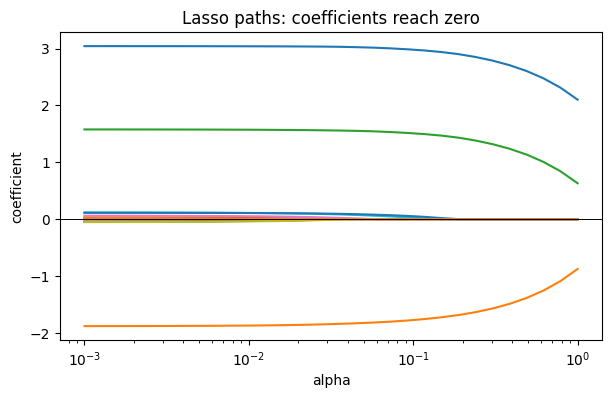

In [2]:
X=rng.normal(size=(150,12)); truth=np.r_[3,-2,1.5,np.zeros(9)]; y=X@truth+rng.normal(0,.8,150); alphas=np.logspace(-3,0,30); paths=[]
for a in alphas:
 p=Pipeline([('scale',StandardScaler()),('lasso',Lasso(alpha=a,max_iter=10000))]).fit(X,y); paths.append(p.named_steps['lasso'].coef_)
plt.figure(figsize=(7,4)); plt.semilogx(alphas,paths); plt.axhline(0,color='k',lw=.7); plt.title('Lasso paths: coefficients reach zero'); plt.xlabel('alpha'); plt.ylabel('coefficient'); plt.show()

With correlated predictors, Lasso may retain one member of a group and zero another. Compare stability across resamples rather than over-interpreting one fit.

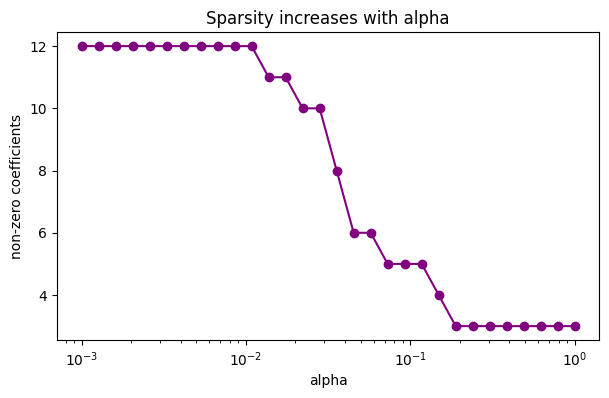

In [3]:
nz=[np.sum(np.abs(c)>1e-8) for c in paths]; plt.figure(figsize=(7,4)); plt.semilogx(alphas,nz,'o-',color='purple'); plt.title('Sparsity increases with alpha'); plt.xlabel('alpha'); plt.ylabel('non-zero coefficients'); plt.show()